# Neural Network (MLP) — Customer Churn Prediction (Telco)

A multi-layer perceptron built with PyTorch. The architecture itself is searched:
Optuna decides the number of layers, the width of each one, whether to use dropout
and batch normalisation, and the optimisation settings.

The pipeline follows the same order as the other notebooks:

1. **Preprocessing** — feature selection, feature engineering, encoding, scaling.
2. **Model definition** — the `FlexibleMLP` class.
3. **Training function** — one reusable loop, used by both the search and the final fit.
4. **Search space** — architecture plus optimiser hyper-parameters.
5. **Objective function** — validation average precision, with per-epoch pruning.
6. **Study** — the actual search.
7. **Threshold selection** — on the validation set, never on test.
8. **Final training and evaluation** — held-out test set.

**One deliberate difference from the other three notebooks.** The tree models and
the logistic regression are tuned with 5-fold cross-validation. Here a single
train/validation split is used instead, for two reasons: training 5 networks per
trial is prohibitively slow on CPU, and a held-out validation set allows *per-epoch*
pruning, which is where most of the savings come from when tuning a network. This
asymmetry is noted again in the final section, because it matters when reading the
comparison table.

This notebook is self-contained: it does not import anything from `src/`.

## 1. Imports and global settings

Neural network training has more sources of randomness than the other models
(weight initialisation, batch shuffling, dropout masks), so the seed is set for
NumPy and PyTorch explicitly.

The device is detected rather than hard-coded, so the notebook runs on a machine
without a GPU.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
N_TRIALS = 30
TEST_SIZE = 0.2
VAL_SIZE = 0.2

np.random.seed(SEED)
torch.manual_seed(SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"pandas {pd.__version__}")
print(f"torch {torch.__version__}")
print(f"Device: {DEVICE}")


/home/alejandropenagos/Escritorio/Alejandro/Machine Learning/customer-churn-prediction/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


pandas 3.0.6
torch 2.7.1+cpu
Device: cpu


## 2. Load and preprocess the dataset

The full pipeline (feature selection, service engineering, cleaning,
encoding, train/test split and standardisation) lives in
`PreprocessingTelco`, so the notebook only consumes the ready-to-model
splits.


In [2]:
from pathlib import Path
import sys

for parent in (Path.cwd(), *Path.cwd().parents):
    if (parent / "w1_supervized_learning").is_dir():
        sys.path.insert(0, str(parent))
        break
else:
    raise ModuleNotFoundError("Could not locate the src directory")

from w1_supervized_learning.data_preprocessing.data_preprocessing_telco import (
    PreprocessingTelco,
)


prep = PreprocessingTelco()
X_train, X_test, y_train, y_test = prep.preprocess()
FEATURE_NAMES = prep.feature_names

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=VAL_SIZE, stratify=y_train, random_state=SEED
)

y_train = np.asarray(y_train)
y_val = np.asarray(y_val)
y_test = np.asarray(y_test)

N_FEATURES = X_train.shape[1]
WEIGHT_RATIO = float((y_train == 0).sum() / (y_train == 1).sum())

print(f"Train: {X_train.shape}  churn rate {y_train.mean():.1%}")
print(f"Val:   {X_val.shape}  churn rate {y_val.mean():.1%}")
print(f"Test:  {X_test.shape}  churn rate {y_test.mean():.1%}")
print(f"Negative/positive ratio in train: {WEIGHT_RATIO:.2f}")


Train: (4500, 22)  churn rate 26.6%
Val:   (1125, 22)  churn rate 26.6%
Test:  (1407, 22)  churn rate 26.6%
Negative/positive ratio in train: 2.76


## 3. Move the data to tensors

The validation and test sets are small enough to live on the device as single
tensors, so they can be evaluated in one forward pass instead of being batched.

`float32` is used throughout: it is the default precision for network weights, and
mixing in `float64` inputs would raise a dtype error at the first matrix multiply.

In [3]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_val_t = torch.tensor(X_val, dtype=torch.float32).to(DEVICE)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)

print(f"X_train_t: {tuple(X_train_t.shape)}  dtype {X_train_t.dtype}")
print(f"X_val_t:   {tuple(X_val_t.shape)}  on {X_val_t.device}")

X_train_t: (4500, 22)  dtype torch.float32
X_val_t:   (1125, 22)  on cpu


## 4. Model definition: `FlexibleMLP`

The architecture is parameterised so Optuna can search it. `hidden_dims` is a list
of layer widths, and each hidden block is `Linear -> [BatchNorm] -> ReLU ->
[Dropout]`.

**The output layer has no activation on purpose.** Training uses
`BCEWithLogitsLoss`, which applies the sigmoid internally in a numerically stable
way (log-sum-exp trick). A separate `Sigmoid` followed by `BCELoss` is
mathematically equivalent but can underflow to `log(0)` and produce `NaN`
gradients. The sigmoid is applied explicitly later, only when probabilities are
needed for scoring.

In [5]:
class FlexibleMLP(nn.Module):
    """
    Flexible Multi-Layer Perceptron for binary classification.

    Args:
        input_dim (int): Number of input features
        hidden_dims (list): List of hidden layer sizes [h1, h2, h3, ...]
        dropout_p (float): Dropout probability (0 = no dropout)
        use_batchnorm (bool): Whether to use batch normalization
    """

    def __init__(self, input_dim, hidden_dims, dropout_p=0.0, use_batchnorm=False):
        super(FlexibleMLP, self).__init__()

        self.input_dim = input_dim
        self.hidden_dims = hidden_dims
        self.dropout_p = dropout_p
        self.use_batchnorm = use_batchnorm

        # Build layers
        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            # Linear layer
            layers.append(nn.Linear(prev_dim, hidden_dim))

            # Batch normalization (if enabled)
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_dim))

            # Activation
            layers.append(nn.ReLU())

            # Dropout (if enabled)
            if dropout_p > 0:
                layers.append(nn.Dropout(dropout_p))

            prev_dim = hidden_dim

        # Output layer (no activation here, we'll use BCEWithLogitsLoss)
        layers.append(nn.Linear(prev_dim, 1))

        self.network = nn.Sequential(*layers)  # NN as a Graph DAG

    def forward(self, x):
        return self.network(x)

    def count_parameters(self):
        """Count total number of trainable parameters"""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


## 5. Probability helper

`model.eval()` matters: it switches dropout off and makes batch normalisation use
its running statistics instead of the batch's. Forgetting it is one of the most
common sources of silently wrong evaluation numbers in PyTorch.

`torch.no_grad()` skips building the autograd graph, which is unnecessary for
inference and saves memory.

In [6]:
def predict_proba(model: nn.Module, X_tensor: torch.Tensor) -> np.ndarray:
    """Return churn probabilities for a tensor already on the target device."""
    model.eval()
    with torch.no_grad():
        logits = model(X_tensor).squeeze(1)
        return torch.sigmoid(logits).cpu().numpy()

## 6. Training function

One loop reused by both the search and the final fit, so they cannot drift apart.

Design points:

- **`pos_weight` in the loss** multiplies the positive class's contribution. This is
  the network's counterpart to `scale_pos_weight` in XGBoost and `class_weight` in
  the forest and the logistic model, so all four notebooks can compensate the
  imbalance.
- **`AdamW`** decouples weight decay from the gradient update, which makes the
  `weight_decay` hyper-parameter behave as actual L2 regularisation. Plain `Adam`
  folds it into the adaptive step and the effect becomes hard to interpret.
- **`drop_last`** guards against a final batch of size 1: `BatchNorm1d` cannot
  compute a variance from a single sample and raises an error in training mode.
- **Per-epoch validation** is what enables pruning. The score is recorded every
  epoch so the objective can report it to Optuna, and so the training curve can be
  plotted later.

In [7]:
def train_model(
    params: dict,
    trial: optuna.Trial | None = None,
    seed: int = SEED,
) -> tuple[nn.Module, list[float]]:
    """Train a FlexibleMLP on the training split, scoring on validation each epoch.

    Args:
        params: Architecture and optimiser hyper-parameters.
        trial: If given, validation scores are reported for pruning.
        seed: Seed for weight initialisation and batch shuffling.

    Returns:
        The trained model and the per-epoch validation average precision.
    """
    torch.manual_seed(seed)
    generator = torch.Generator().manual_seed(seed)

    batch_size = params["batch_size"]
    dataset = TensorDataset(X_train_t, y_train_t)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator,
        drop_last=params["use_batchnorm"] and len(dataset) % batch_size == 1,
    )

    model = FlexibleMLP(
        input_dim=N_FEATURES,
        hidden_dims=params["hidden_dims"],
        dropout_p=params["dropout_p"],
        use_batchnorm=params["use_batchnorm"],
    ).to(DEVICE)

    optimizer = optim.AdamW(
        model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"]
    )
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor(params["pos_weight"], device=DEVICE)
    )

    val_history: list[float] = []

    for epoch in range(params["epochs"]):
        model.train()
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()
            logits = model(X_batch).squeeze(1)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

        val_score = average_precision_score(y_val, predict_proba(model, X_val_t))
        val_history.append(float(val_score))

        if trial is not None:
            trial.report(val_score, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

    return model, val_history

## 7. Hyper-parameter search space

**Architecture**
- `n_layers` (1–4) and one width per layer (16–128, step 16). The widths are sampled
  independently, so the search can discover funnel shapes such as `[128, 64, 32]` as
  well as uniform ones.
- `hidden_dims` is therefore a **derived** parameter: Optuna samples `n_layers` and
  `hidden_dim_0..3`, and they are assembled into the list the model expects. Section
  13 has to rebuild it from `study.best_params` for exactly this reason.

**Regularisation**
- `dropout_p` (0–0.5) and `use_batchnorm`. Both are searched rather than assumed,
  since on a tabular dataset of this size they can just as easily hurt as help.
- `weight_decay`, on a log scale.

**Optimisation**
- `lr` on a log scale — it spans orders of magnitude and is usually the single most
  important hyper-parameter.
- `epochs` (20–100). Tuned rather than early-stopped, to keep one single validation
  scheme; pruning already cuts off runs that are going nowhere.
- `batch_size` — affects both gradient noise and how many updates an epoch performs.

**Imbalance**
- `pos_weight`, bounded by the dataset's own ratio so the space transfers to the
  Telecom dataset unchanged.

In [8]:
UPPER_POS_WEIGHT = max(WEIGHT_RATIO * 2.0, 1.5)


def suggest_params(trial: optuna.Trial) -> dict:
    """Sample one architecture and optimiser configuration."""
    n_layers = trial.suggest_int("n_layers", 1, 4)
    hidden_dims = [
        trial.suggest_int(f"hidden_dim_{index}", 16, 128, step=16)
        for index in range(n_layers)
    ]

    return {
        "hidden_dims": hidden_dims,
        "dropout_p": trial.suggest_float("dropout_p", 0.0, 0.5),
        "use_batchnorm": trial.suggest_categorical("use_batchnorm", [True, False]),
        "lr": trial.suggest_float("lr", 1e-4, 1e-1, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
        "epochs": trial.suggest_int("epochs", 20, 100, step=10),
        "batch_size": trial.suggest_categorical("batch_size", [32, 64, 128, 256]),
        "pos_weight": trial.suggest_float(
            "pos_weight", 1.0, UPPER_POS_WEIGHT, log=True
        ),
    }


print(f"pos_weight will be searched in [1.0, {UPPER_POS_WEIGHT:.2f}]")

pos_weight will be searched in [1.0, 5.53]


## 8. Objective function

**Why average precision?** Accuracy is useless here: predicting "nobody churns"
already scores ~73%. Average precision summarises the whole precision-recall curve,
so it measures how well the network *ranks* customers by risk, independently of any
threshold — which is not chosen until section 15.

It is also not the same thing as the training loss. `BCEWithLogitsLoss` is what
gradient descent minimises; average precision is what we use to compare
configurations. A configuration can reach a lower loss and still rank worse.

**Why the returned score is the last epoch's.** `train_model` reports every epoch
for pruning, and the objective returns the final value, which is the score of the
model that actually comes out of training. Returning `max(val_history)` instead
would be optimistic: it would credit the configuration for an epoch whose weights
were then discarded.

In [9]:
def objective(trial: optuna.Trial) -> float:
    """Validation average precision after training one configuration."""
    params = suggest_params(trial)
    _, val_history = train_model(params, trial=trial)
    return val_history[-1]

## 9. Run the study

`MedianPruner(n_warmup_steps=5)` gives every trial 5 epochs before it can be
killed, since a network's first epochs are noisy and an early lead means little.
After that, any trial below the median of the others at the same epoch is stopped.
This is where the time savings come from: bad architectures are abandoned after a
few epochs instead of running all 100.

`N_TRIALS` defaults to 30 rather than the 50 used in the other notebooks, because
each trial trains a network from scratch. This is the slowest cell in the whole
workshop; lower it in section 1 to smoke-test the pipeline.

In [10]:
study = optuna.create_study(
    study_name="neural_network_telco",
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"Best validation average precision: {study.best_value:.4f}")
print("Best hyper-parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

completed = [t for t in study.trials if t.state.name == "COMPLETE"]
pruned = [t for t in study.trials if t.state.name == "PRUNED"]
print(f"\nTrials: {len(completed)} completed, {len(pruned)} pruned")

Best trial: 24. Best value: 0.643293: 100%|██████████| 30/30 [00:57<00:00,  1.90s/it]

Best validation average precision: 0.6433
Best hyper-parameters:
  n_layers: 1
  hidden_dim_0: 80
  dropout_p: 0.3555268345219509
  use_batchnorm: True
  lr: 0.00035323308325840917
  weight_decay: 0.0002218255964847542
  epochs: 20
  batch_size: 128
  pos_weight: 1.9833488963985237

Trials: 19 completed, 11 pruned


## 10. Rebuild the best configuration

`study.best_params` holds the **flat** values Optuna sampled (`n_layers`,
`hidden_dim_0`, `hidden_dim_1`, ...), not the assembled `hidden_dims` list that
`FlexibleMLP` takes. It has to be reconstructed in the same way `suggest_params`
built it.

This is a genuine trap: passing `study.best_params` straight into the model would
silently train a *different* architecture from the one that won the search.

In [11]:
flat = study.best_params

best_params = {
    "hidden_dims": [flat[f"hidden_dim_{i}"] for i in range(flat["n_layers"])],
    "dropout_p": flat["dropout_p"],
    "use_batchnorm": flat["use_batchnorm"],
    "lr": flat["lr"],
    "weight_decay": flat["weight_decay"],
    "epochs": flat["epochs"],
    "batch_size": flat["batch_size"],
    "pos_weight": flat["pos_weight"],
}

print(f"Architecture: {N_FEATURES} -> {' -> '.join(map(str, best_params['hidden_dims']))} -> 1")
for key, value in best_params.items():
    if key != "hidden_dims":
        print(f"  {key}: {value}")

Architecture: 22 -> 80 -> 1
  dropout_p: 0.3555268345219509
  use_batchnorm: True
  lr: 0.00035323308325840917
  weight_decay: 0.0002218255964847542
  epochs: 20
  batch_size: 128
  pos_weight: 1.9833488963985237


## 11. Final training

The winning configuration is retrained on the training split, with the validation
set monitored each epoch so the learning curve can be inspected.

**Why not retrain on train + validation?** The other notebooks refit on their whole
training set, and doing the same here would give the network ~20% more data. But the
decision threshold in the next cell is chosen on validation, so a model that had
already trained on validation would make that choice optimistic. Keeping validation
genuinely held out costs some data and buys an honest threshold. The trade-off is
listed in the final section.

In [12]:
final_model, val_history = train_model(best_params)

print(f"Trained on {X_train.shape[0]} rows for {best_params['epochs']} epochs")
print(f"Trainable parameters: {final_model.count_parameters():,}")
print(f"Final validation average precision: {val_history[-1]:.4f}")

Trained on 4500 rows for 20 epochs
Trainable parameters: 2,081
Final validation average precision: 0.6433


## 12. Learning curve

Validation average precision per epoch, for the winning configuration. What to look
for:

- **Still rising at the end** — `epochs` was capped too low; the model was cut off
  while still improving.
- **Rises then falls** — overfitting. The tuned `epochs` should have landed near the
  peak; if it clearly did not, early stopping would help.
- **Flat from the start** — the learning rate is likely too low, or the architecture
  too small to fit the signal.

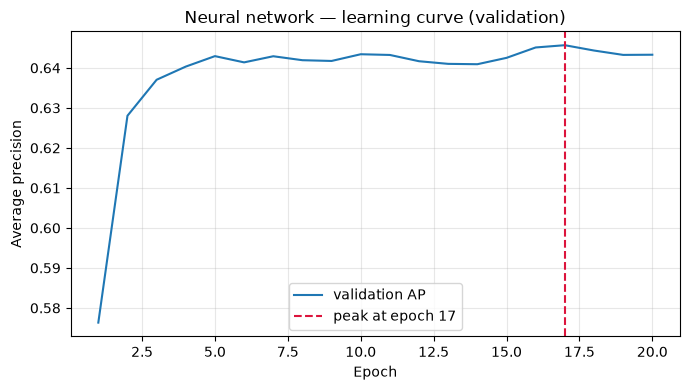

In [13]:
best_epoch = int(np.argmax(val_history)) + 1

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(val_history) + 1), val_history, label="validation AP")
ax.axvline(best_epoch, color="crimson", linestyle="--", label=f"peak at epoch {best_epoch}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Average precision")
ax.set_title("Neural network — learning curve (validation)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Threshold selection on the validation set

The sigmoid output is a probability; turning it into a decision needs a cut. The
default 0.5 is arbitrary and, with `pos_weight` already shifting the probabilities
upwards, particularly unsuited here.

The cut is chosen on **validation**, which the final model never trained on. The
other notebooks use out-of-fold probabilities for the same purpose; the principle is
identical — never tune the threshold on test.

Best threshold: 0.49  (validation F1 = 0.6206)
F1 at the default 0.50: 0.6122


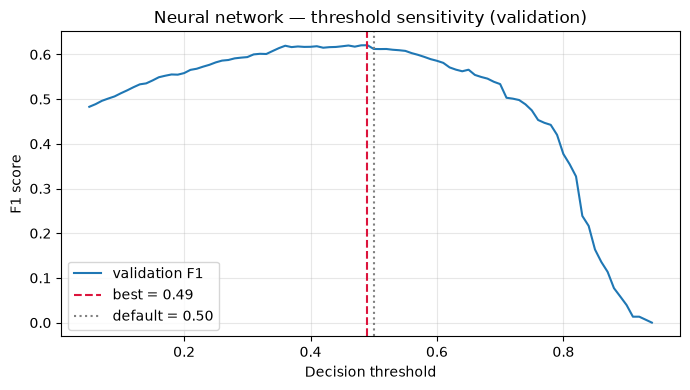

In [14]:
val_proba = predict_proba(final_model, X_val_t)

thresholds = np.arange(0.05, 0.95, 0.01)
val_f1 = [f1_score(y_val, (val_proba >= t).astype(int)) for t in thresholds]

best_threshold = float(thresholds[int(np.argmax(val_f1))])
print(f"Best threshold: {best_threshold:.2f}  (validation F1 = {max(val_f1):.4f})")
print(f"F1 at the default 0.50: {f1_score(y_val, (val_proba >= 0.5).astype(int)):.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, val_f1, label="validation F1")
ax.axvline(best_threshold, color="crimson", linestyle="--", label=f"best = {best_threshold:.2f}")
ax.axvline(0.5, color="grey", linestyle=":", label="default = 0.50")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("F1 score")
ax.set_title("Neural network — threshold sensitivity (validation)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 14. Evaluation on the test set

The test set is touched exactly once, here.

Metrics are ordered from most to least informative for this problem.
`average_precision` and `roc_auc` judge the ranking and are threshold-free;
`f1`, `recall` and `precision` judge the decisions at the chosen cut.
**`accuracy` is last on purpose** — a model predicting "no churn" for everyone
scores ~73% here.

In [15]:
test_proba = predict_proba(final_model, X_test_t)
test_preds = (test_proba >= best_threshold).astype(int)

metrics = {
    "average_precision": average_precision_score(y_test, test_proba),
    "roc_auc": roc_auc_score(y_test, test_proba),
    "f1": f1_score(y_test, test_preds),
    "recall": recall_score(y_test, test_preds),
    "precision": precision_score(y_test, test_preds),
    "balanced_accuracy": balanced_accuracy_score(y_test, test_preds),
    "accuracy": accuracy_score(y_test, test_preds),
}

print(f"Threshold used: {best_threshold:.2f}\n")
pd.Series(metrics, name="neural_network").to_frame().round(4)

Threshold used: 0.49



,neural_network
average_precision,0.6130
roc_auc,0.8292
f1,0.6110
recall,0.7246
precision,0.5283
balanced_accuracy,0.7452
accuracy,0.7548


## 15. Confusion matrix

The business reading of the two error types:

- **False negatives** — churners the model missed. Direct lost revenue.
- **False positives** — loyal customers flagged as at-risk. Cost of a wasted
  retention offer.

Which one hurts more depends on the margin per customer versus the cost of the
offer, and that is exactly the trade-off the threshold controls.

In [16]:
tn, fp, fn, tp = confusion_matrix(y_test, test_preds).ravel()

pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["actual: stays", "actual: churns"],
    columns=["predicted: stays", "predicted: churns"],
)

,predicted: stays,predicted: churns
actual: stays,791,242
actual: churns,103,271


## 16. Notes and limitations

**What this notebook establishes.** A tuned MLP whose architecture was searched
rather than assumed, with an honestly selected decision threshold.

**Limitations, and they matter more here than in the other notebooks.**

- **Different validation scheme.** The other three models are tuned with 5-fold
  cross-validation; this one uses a single train/validation split. Its
  hyper-parameters were therefore selected against ~1100 validation rows instead of
  the whole training set, which is a noisier signal. State this when presenting the
  comparison table.
- **Less training data in the final fit.** To keep the threshold honest, the final
  model trains on ~4500 rows while the other models refit on ~5600. Part of any gap
  in the results is this, not the model class.
- **Fewer trials.** 30 versus 50, for runtime reasons. The network gets a smaller
  search budget on a larger space (architecture *and* optimisation), which is the
  opposite of favourable.
- **No interpretability.** There is no equivalent of the logistic coefficients or
  the tree importances. Attribution would need a dedicated method such as integrated
  gradients or SHAP.
- **Neural networks are rarely the right tool for ~7000 rows of tabular data.**
  Gradient-boosted trees are the usual state of the art in this regime. If this
  notebook loses to XGBoost, that is the expected result and worth reporting as a
  finding rather than a failure.

